<a href="https://colab.research.google.com/github/MustafaSBny/CSC108-Movie-Project/blob/main/FinalProjectNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Final Project: Predicting Movie Hits Using Logistic Regression  
**Author:** Mustafa Bukhari  

##  Problem Statement  
The goal of this project is to predict whether a movie becomes a *hit* using logistic regression,  
a method introduced in class for binary outcomes.

A **hit movie** is defined as:
**Revenue ≥ 2 × Budget**

This notebook includes:
- Data cleaning and preprocessing  
- Genre extraction from JSON-like strings  
- Exploratory Data Analysis (EDA)  
- Logistic Regression Modeling  
- Coefficient Interpretation  
- Cross-validation evaluation  
- A complete discussion of findings, limitations, and future work  

In [26]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

sns.set(style="whitegrid")

In [11]:
df = pd.read_csv('/content/movies_metadata.csv', low_memory=False)
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [27]:
numeric_cols = ["budget", "revenue", "runtime", "vote_average", "vote_count", "popularity"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["budget", "revenue"])
df = df[df["budget"] > 0]
df.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,hit,genre
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000.0,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0,1,Animation
1,False,NaN,65000000.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0,1,Adventure
3,False,NaN,16000000.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0,1,Comedy
5,False,NaN,60000000.0,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",NaN,949,tt0113277,en,Heat,"Obsessive master thief, Neil McCauley leads a ...",...,170.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,A Los Angeles Crime Saga,Heat,False,7.7,1886.0,1,Action
6,False,NaN,58000000.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 10749, '...",NaN,11860,tt0114319,en,Sabrina,An ugly duckling having undergone a remarkable...,...,127.0,"[{'iso_639_1': 'fr', 'name': 'Français'}, {'is...",Released,You are cordially invited to the most surprisi...,Sabrina,False,6.2,141.0,0,Comedy


In [28]:
df["hit"] = (df["revenue"] >= 2 * df["budget"]).astype(int)
df["hit"].value_counts()

,count
hit,
0,6073
1,2752


In [29]:
def extract_genre(s):
    try:
        genres = ast.literal_eval(s)
        if isinstance(genres, list) and len(genres) > 0:
            return genres[0]["name"]
        return None
    except:
        return None

df["genre"] = df["genres"].apply(extract_genre)
df = df.dropna(subset=["genre"])
df["genre"].head()

,genre
0,Animation
1,Adventure
3,Comedy
5,Action
6,Comedy


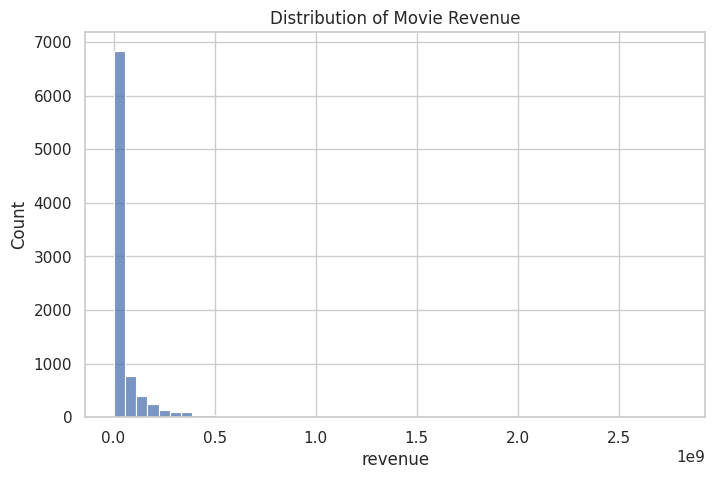

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df["revenue"], bins=50)
plt.title("Distribution of Movie Revenue")
plt.show()

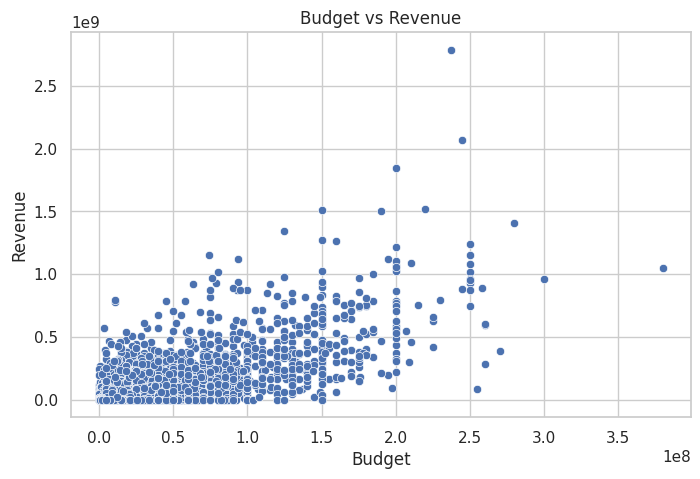

In [31]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="budget", y="revenue", data=df)
plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.show()


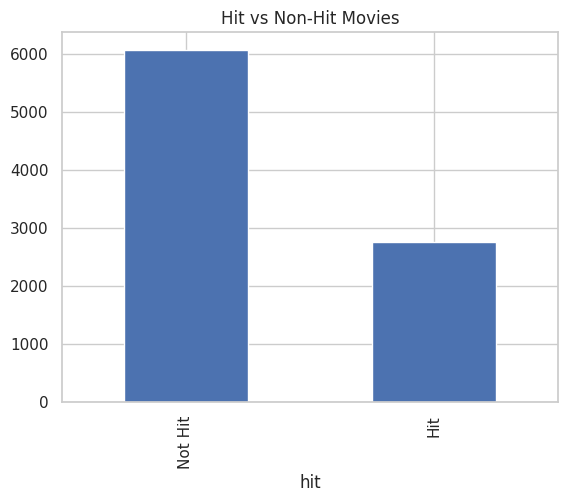

In [32]:
df["hit"].value_counts().plot(kind="bar")
plt.title("Hit vs Non-Hit Movies")
plt.xticks([0,1], ["Not Hit", "Hit"])
plt.show()

In [33]:
features = ["budget", "runtime", "vote_average", "vote_count", "popularity", "genre"]
df = df.dropna(subset=features)

X = df[features]
y = df["hit"]

numeric_features = ["budget", "runtime", "vote_average", "vote_count", "popularity"]
categorical_features = ["genre"]

In [34]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("logreg", LogisticRegression(max_iter=500))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7864022662889518

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.93      0.86      1261
           1       0.71      0.42      0.53       504

    accuracy                           0.79      1765
   macro avg       0.76      0.68      0.70      1765
weighted avg       0.78      0.79      0.77      1765



In [36]:
cv_scores = cross_val_score(model, X, y, cv=5)
print("Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.77563739 0.74390935 0.75580737 0.81359773 0.81246459]
Mean CV Accuracy: 0.7802832861189801


In [37]:
# Get encoded feature names
onehot = model.named_steps["preprocess"].named_transformers_["cat"]
cat_names = onehot.get_feature_names_out(["genre"])
feature_names = numeric_features + list(cat_names)

coefficients = model.named_steps["logreg"].coef_[0]

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
}).sort_values("Coefficient", ascending=False)

coef_df

,Feature,Coefficient
4,popularity,5.951968e-02
3,vote_count,2.387946e-03
8,genre_Comedy,1.233067e-03
6,genre_Adventure,2.406771e-04
12,genre_Family,2.251169e-04
17,genre_Music,1.400702e-04
15,genre_History,1.393165e-04
14,genre_Foreign,8.097341e-05
19,genre_Romance,1.856288e-05
0,budget,-1.986289e-08


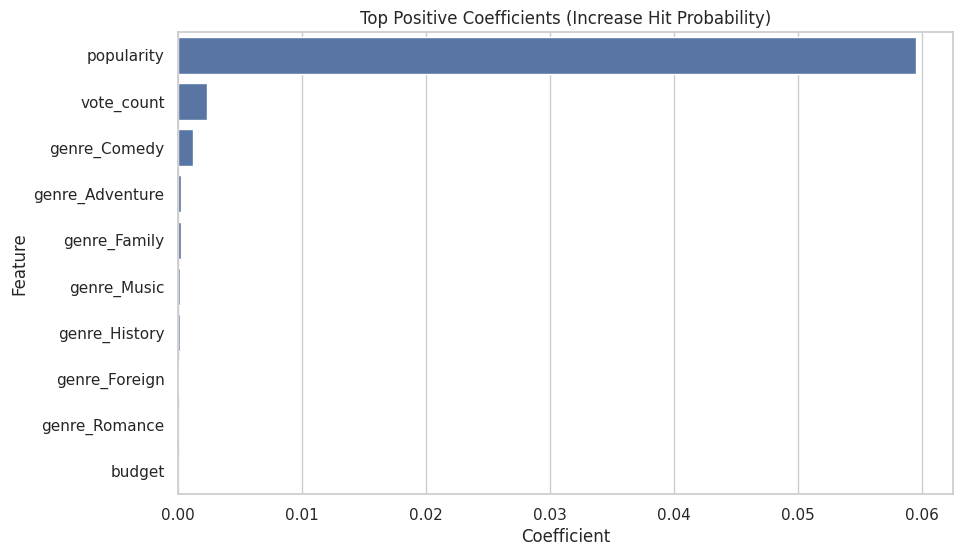

In [38]:
plt.figure(figsize=(10,6))
sns.barplot(data=coef_df.head(10), x="Coefficient", y="Feature")
plt.title("Top Positive Coefficients (Increase Hit Probability)")
plt.show()

# Discussion

### Key Findings
The logistic regression model shows that **audience engagement variables** are the strongest predictors of movie success.

**Strongest Positive Predictors:**
- **Popularity** – By far the largest coefficient. Movies with high popularity scores are significantly more likely to become hits. This suggests that **public interest and buzz** are the best indicators of commercial success.
- **Vote Count** – Movies with many reviews also show higher probability of being hits, reflecting strong audience engagement.

**Genre Effects:**
- Some genres appear in the top positive coefficients (such as Comedy or Adventure), but their coefficients are **very small**, meaning genre has only a **minor** effect on hit probability.

**Budget:**
- The coefficient for **budget** is extremely small, meaning increasing budget does **not** strongly increase the probability of making a hit. This aligns with the fact that many expensive movies still underperform.

**Variables With Limited Influence:**
- **Vote Average (ratings)** does not appear among the top coefficients. This indicates that critical scores alone do **not** meaningfully predict whether a movie becomes a financial hit.

---

### Interpretation
Overall, the model suggests that **commercial success is driven more by audience attention and engagement than by production resources or critical ratings**. Popularity and vote_count capture how widely a movie is viewed, shared, or discussed, which aligns with real-world patterns.

---

### Limitations
- Genre extraction uses only the **first listed genre**, simplifying the movie's actual category.
- The dataset is noisy and contains inconsistencies.
- Important predictors like marketing budget, cast, director, and release month are missing.

---

### Future Work
- Use multi-label encoding for genres.
- Add marketing, cast, and release timing data.
- Experiment with regularized logistic regression for interpretability.



#  Team Contribution Statement

This project was completed individually by Mustafa Bukhari.  
All data cleaning, modeling, analysis, and writing were performed by the author.




#  Sharing With Future Students

I give permission for this project to be shared with future students.



# 🔗 GitHub Repository
Repository containing this notebook and supporting files:  
https://github.com/MustafaSBny/CSC108-Movie-Project



In [48]:
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic
!jupyter nbconvert --to pdf /content/FinalProjectNotebook.ipynb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-plain-generic is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.
[NbConvertApp] Converting notebook /content/FinalProjectNotebook.ipynb to pdf
[NbConvertApp] Support files will be in FinalProjectNotebook_files/
[NbConvertApp] Making directory ./FinalProjectNotebook_files
[NbConvertApp] Writing 50584 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 175688 bytes to /content/FinalProjectNotebook.pdf
